In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Зашумить изображение при помощи шума гаусса, постоянного шума.

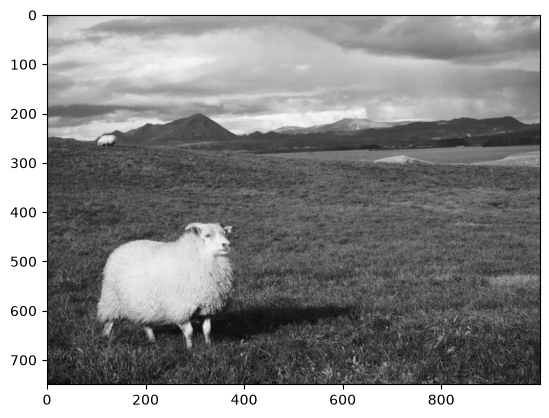

In [9]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

plt.imshow(image_gray, cmap="gray")

In [31]:
# гауссов шум
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[ 14,   0,   0, ...,   0,   0, 224],
       [211, 194,   0, ...,  83, 174,  51],
       [  0,   0,  67, ..., 137,   0,  12],
       ...,
       [  0,   0,   0, ...,  37, 101,   0],
       [  3,   0,   0, ...,  15,   0,   0],
       [145,  22,  26, ...,   0,   0,  10]],
      shape=(750, 1000), dtype=uint8)

Text(0.5, 1.0, 'Изображение с шумом')

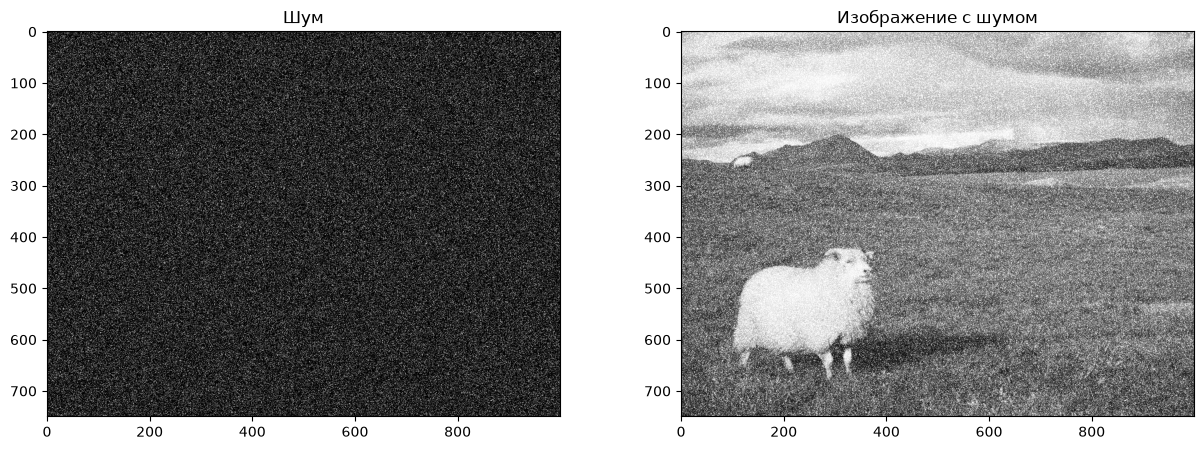

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(noise_gauss, cmap="gray")
axes[0].set_title('Шум')

image_noise_gauss = cv2.add(image_gray,noise_gauss)
axes[1].imshow(image_noise_gauss, cmap="gray")
axes[1].set_title('Изображение с шумом')

In [7]:
# постоянный шум (соль-перец)
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

bg_image = np.ones(image_gray.shape, np.uint8) * 128

bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

Text(0.5, 1.0, 'Изображение с шумом')

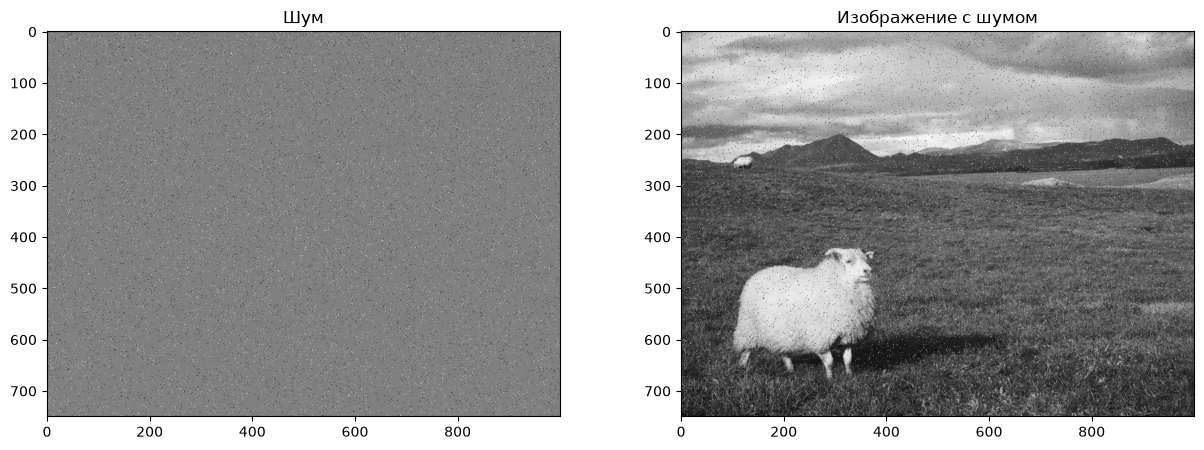

In [28]:
import copy

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(bg_image, cmap="gray")
axes[0].set_title('Шум')

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel]  = 255
axes[1].imshow(image_sp, cmap="gray")
axes[1].set_title('Изображение с шумом')

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [21]:
from skimage.metrics import structural_similarity, mean_squared_error

In [27]:
# для гаусса
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print('Gauss:', mse_gauss, ssim_gauss)

# для соль-перца
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print('Salt Pepper:', mse_sp, ssim_sp)

Gauss: 3294.275312 0.1426595291657367
Salt Pepper: 392.4280586666667 0.6260306584849423


In [33]:
# медианный фильтр
# для гаусса
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

print('Gauss:', mse_gauss_median, ssim_gauss_median)

# для соль-перца
image_sp_median = cv2.medianBlur(image_sp, 3)

mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print('Salt Pepper:', mse_sp_median, ssim_sp_median)

Gauss: 882.5616693333334 0.31943981689139805
Salt Pepper: 61.274932 0.8511847410577676


In [34]:
# фильтр гаусса
# для гаусса
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)

print('Gauss:', mse_gauss_gauss, ssim_gauss_gauss)

# для соли-перца
image_sp_gauss = cv2.GaussianBlur(image_sp,(5,5),0)

mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss)
(ssim_sp_gauss, _) = structural_similarity(image_gray, image_sp_gauss, full=True)

print('Salt Pepper:', mse_sp_gauss, ssim_sp_gauss)

Gauss: 1384.08208 0.49010835032994216
Salt Pepper: 94.80515066666666 0.7293817583632423


In [35]:
# билатериальный фильтр
# для гаусса
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, _) = structural_similarity(image_gray, image_gauss_bilat, full=True)

print('Gauss:', mse_gauss_bilat, ssim_gauss_bilat)

# для соли-перца
image_sp_bilat = cv2.bilateralFilter(image_sp,9,75,75)

mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat)
(ssim_sp_bilat, _) = structural_similarity(image_gray, image_sp_bilat, full=True)

print('Salt Pepper:', mse_sp_bilat, ssim_sp_bilat)

Gauss: 1383.9334533333333 0.39205403677172884
Salt Pepper: 173.12032133333332 0.5756642427237536


In [38]:
# фильтр нелокальных средних
# для гаусса
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, _) = structural_similarity(image_gray, image_gauss_nlm, full=True)

print('Gauss:', mse_gauss_nlm, ssim_gauss_nlm)

# для соль-перца
image_sp_nlm = cv2.fastNlMeansDenoising(image_sp, h=20)

mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm)
(ssim_sp_nlm, _) = structural_similarity(image_gray, image_sp_nlm, full=True)
    
print('Salt Pepper:', mse_sp_nlm, ssim_sp_nlm)

Gauss: 3116.605658666667 0.26362468040133946
Salt Pepper: 148.54833333333335 0.621816460618029


# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [60]:
table = np.array([
    [mse_gauss, ssim_gauss, mse_sp, ssim_sp],
    [mse_gauss_median, ssim_gauss_median, mse_sp_median, ssim_sp_median],
    [mse_gauss_gauss, ssim_gauss_gauss, mse_sp_gauss, ssim_sp_gauss],
    [mse_gauss_bilat, ssim_gauss_bilat, mse_sp_bilat, ssim_sp_bilat],
    [mse_gauss_nlm, ssim_gauss_nlm, mse_sp_nlm, ssim_sp_nlm],
])
labels = ['Noisy', 'Median', 'Gaussian', 'Bilateral', 'NLM']

for i, name in enumerate(labels):
    mse_g, ssim_g, mse_s, ssim_s = table[i]
    print(f'{name:<10}'
          f'gauss: MSE={mse_g:>8.2f}, SSIM={ssim_g:.2f}  '
          f'sp: MSE={mse_s:>7.2f}, SSIM={ssim_s:.2f}')

Noisy     gauss: MSE= 3294.28, SSIM=0.14  sp: MSE= 392.43, SSIM=0.63
Median    gauss: MSE=  882.56, SSIM=0.32  sp: MSE=  61.27, SSIM=0.85
Gaussian  gauss: MSE= 1384.08, SSIM=0.49  sp: MSE=  94.81, SSIM=0.73
Bilateral gauss: MSE= 1383.93, SSIM=0.39  sp: MSE= 173.12, SSIM=0.58
NLM       gauss: MSE= 3116.61, SSIM=0.26  sp: MSE= 148.55, SSIM=0.62


In [56]:
# лучший результат фильтрации для гаусса

# индекс строки с минимальным gauss_MSE
idx_best_gauss_mse = numpy.argmin(table[:, 0])
# индекс строки с максимальным gauss_SSIM
idx_best_gauss_ssim = numpy.argmax(table[:, 1])

print('Лучший по MSE для гаусса:')
print(f'{labels[idx_best_gauss_mse]}: '
      f'gauss_MSE={table[idx_best_gauss_mse, 0]:.2f}, '
      f'gauss_SSIM={table[idx_best_gauss_mse, 1]:.4f}')

print()
print('Лучший по SSIM для гаусса:')
print(f'{labels[idx_best_gauss_ssim]}: '
      f'gauss_MSE={table[idx_best_gauss_ssim, 0]:.2f}, '
      f'gauss_SSIM={table[idx_best_gauss_ssim, 1]:.4f}')

Лучший по MSE для гаусса:
Median: gauss_MSE=882.56, gauss_SSIM=0.3194

Лучший по SSIM для гаусса:
Gaussian: gauss_MSE=1384.08, gauss_SSIM=0.4901


In [61]:
# лучший результат фильтрации для соли-перца

# индекс строки с минимальным sp_MSE
idx_best_sp_mse = numpy.argmin(table[:, 2])
# индекс строки с максимальным sp_SSIM
idx_best_sp_ssim = numpy.argmax(table[:, 3])

print('Лучший по MSE для соль-перца:')
print(f'{labels[idx_best_sp_mse]}: '
      f'sp_MSE={table[idx_best_sp_mse, 2]:.2f}, '
      f'sp_SSIM={table[idx_best_sp_mse, 3]:.4f}')

print()
print('Лучший по SSIM для соль-перца:')
print(f'{labels[idx_best_sp_ssim]}: '
      f'sp_MSE={table[idx_best_sp_ssim, 2]:.2f}, '
      f'sp_SSIM={table[idx_best_sp_ssim, 3]:.4f}')

Лучший по MSE для соль-перца:
Median: sp_MSE=61.27, sp_SSIM=0.8512

Лучший по SSIM для соль-перца:
Median: sp_MSE=61.27, sp_SSIM=0.8512
